## Install Required Libraries

In [10]:
!pip install numpy scikit-learn pyts torch matplotlib sktime==0.30.0 --quiet
!pip install git+https://github.com/gon-uri/detach_rocket --quiet

ERROR: Ignored the following versions that require a different python version: 0.10.0 Requires-Python >=3.7,<3.10; 0.10.1 Requires-Python >=3.7,<3.10; 0.11.0 Requires-Python >=3.7,<3.10; 0.11.1 Requires-Python >=3.7,<3.10; 0.11.2 Requires-Python >=3.7,<3.10; 0.11.3 Requires-Python >=3.7,<3.10; 0.11.4 Requires-Python >=3.7,<3.10; 0.12.0 Requires-Python >=3.7,<3.10; 0.12.1 Requires-Python >=3.7,<3.10; 0.13.0 Requires-Python >=3.7,<3.11; 0.13.1 Requires-Python >=3.7,<3.11; 0.13.2 Requires-Python >=3.7,<3.11; 0.13.3 Requires-Python >=3.7,<3.11; 0.13.4 Requires-Python >=3.7,<3.11; 0.14.0 Requires-Python >=3.7,<3.11; 0.14.1 Requires-Python <3.11,>=3.7; 0.15.0 Requires-Python <3.11,>=3.7; 0.15.1 Requires-Python <3.11,>=3.7; 0.16.0 Requires-Python <3.11,>=3.7; 0.16.1 Requires-Python <3.12,>=3.7; 0.17.0 Requires-Python <3.12,>=3.7; 0.17.1 Requires-Python <3.12,>=3.7; 0.17.2 Requires-Python <3.12,>=3.7; 0.18.0 Requires-Python <3.12,>=3.7; 0.18.1 Requires-Python <3.12,>=3.7; 0.19.0 Requires-Pytho

## Download Dataset from UEA

In [11]:
# Download Dataset
from detach_rocket.utils_datasets import fetch_uea_dataset

dataset_name_list = ['SelfRegulationSCP1'] 
current_dataset = fetch_uea_dataset(dataset_name_list[0])

## Prepare Dataset Matrices

In [12]:
print(f"Dataset Matrix Shape: ( # of instances , # of channels , time series length )")
print(f" ")

# Train Matrix
X_train = current_dataset['data_train']
print(f"Train: {X_train.shape}")
y_train = current_dataset['target_train']

print(f" ")

# Test Matrix
X_test = current_dataset['data_test']
print(f"Test: {X_test.shape}")
y_test = current_dataset['target_test']

Dataset Matrix Shape: ( # of instances , # of channels , time series length )
 
Train: (268, 6, 896)
 
Test: (293, 6, 896)


In [13]:
current_dataset

{'data_train': array([[[ 23.  ,  21.66,  20.84, ...,  21.84,  22.62,  21.5 ],
         [ 19.03,  19.19,  21.5 , ...,  27.03,  26.78,  28.94],
         [ 32.19,  36.81,  40.16, ...,  32.5 ,  34.53,  37.12],
         [ 43.66,  41.22,  39.69, ...,  50.06,  50.84,  50.75],
         [ 30.72,  31.81,  31.69, ...,  44.69,  43.69,  41.88],
         [ 39.09,  39.53,  40.59, ...,  44.03,  44.75,  46.19]],
 
        [[ 29.62,  29.  ,  28.66, ...,  42.09,  38.  ,  34.97],
         [ 27.19,  27.56,  27.91, ..., -10.78, -10.28,  -9.03],
         [ 27.94,  26.19,  23.94, ...,  -3.97,  -2.66,  -2.38],
         [ 19.38,  20.66,  22.78, ...,  -4.84,  -5.47,  -5.78],
         [ 35.44,  38.81,  40.41, ...,  -3.66,  -1.84,   1.62],
         [ 32.25,  30.16,  29.44, ...,  12.88,  11.81,   9.75]],
 
        [[ 24.41,  25.12,  26.06, ...,  23.88,  23.94,  24.03],
         [ 29.41,  30.31,  30.53, ..., -14.19, -12.78, -12.38],
         [ 28.69,  24.62,  21.72, ...,  -8.16,  -8.06,  -9.22],
         [ 15.31,  1

## Train and Evaluate the Model

In [14]:
from detach_rocket.detach_classes import DetachEnsemble
from sklearn.metrics import accuracy_score

# Select initial model characteristics
num_models = 5
num_kernels = 1000

# Create model object
DetachEnsembleModel = DetachEnsemble(num_models=num_models, num_kernels=num_kernels)

# Train Model
DetachEnsembleModel.fit(X_train, y_train)

# Evaluate Performance on Train set
y_train_pred = DetachEnsembleModel.predict(X_train)
print('Train Accuracy: {:.2f}%'.format(100*accuracy_score(y_train, y_train_pred)))

y_test_pred = DetachEnsembleModel.predict(X_test)
print('Test Accuracy: {:.2f}%'.format(100*accuracy_score(y_test, y_test_pred)))

TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 428.13
Train Accuraccy Full ROCKET: 98.51%
-------------------------
TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 37.93
Train Accuraccy Detach Model: 95.15%
-------------------------
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 428.13
Train Accuraccy Full ROCKET: 98.51%
-------------------------
TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 428.13
Train Accuraccy Detach Model: 94.40%
-------------------------
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 428.13
Train Accuraccy Full ROCKET: 98.51%
-------------------------
TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 37.93
Train Accuraccy Detach Model: 92.91%
-------------------------
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 428.13
Train Accuraccy Full ROCKET: 98.88%
-------------------------
TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 37.93
Train Accuraccy Detach Model: 99.25%
---------

## Estimate and plot channel relevance

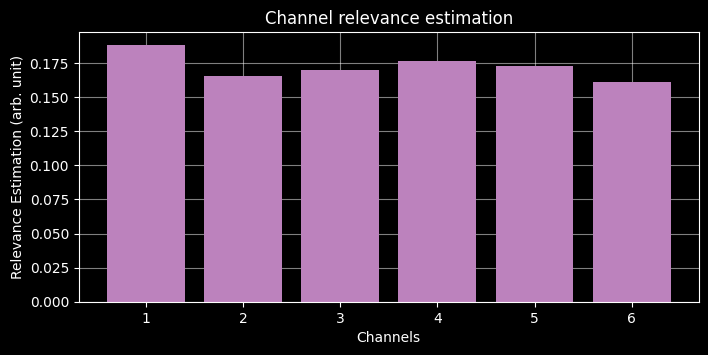

In [15]:
import matplotlib.pyplot as plt

x = range(1, DetachEnsembleModel.num_channels + 1)
channel_relevance = DetachEnsembleModel.estimate_channel_relevance()

plt.figure(figsize=(8,3.5))
plt.bar(x, channel_relevance, color='C7', zorder=2)

plt.title('Channel relevance estimation')
plt.grid(True, linestyle='-', alpha=0.5, zorder=1)
plt.xlabel('Channels')
plt.ylabel('Relevance Estimation (arb. unit)')
plt.show()